# **507 Final Project**

Author: Xingyu Liu

Dataset from Hugging face: [Skincare_Reaction](https://huggingface.co/datasets/misbahbagwan/Skincare-Reaction)

Code and report are linked to Github: [Github Repository](https://github.com/LiuXingyu627/STATS-507-UofM-)

In [1]:
import pandas as pd
import numpy as np

In [2]:
#read dataset from hugging face
df = pd.read_csv("hf://datasets/misbahbagwan/Skincare-Reaction/skincare_data.csv")
df.head()

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


,Age,Melanin Concentration,Collagen Amount,Epidermis Thickness,Hydration Level,Skin Type,Ingredient,Concentration,Neutral Reaction,Positive Reaction,Brightening Reaction,Irritation Reaction,Negative Reaction
0,56,24.699074,53.752102,0.328596,63.223815,Sensitive,Salicylic Acid,10.831598,0.0,0.0,0.0,0.0,0.0
1,46,37.731765,62.010655,0.212318,58.360504,Sensitive,Azelaic Acid,7.275297,0.0,0.0,0.0,0.0,0.0
2,32,5.145802,73.572630,NaN,39.012023,Normal,Vitamin C,15.137619,0.0,1.0,1.0,0.0,0.0
3,60,26.824068,50.448681,0.122448,35.513165,Dry,Glycolic Acid,1.334878,0.0,0.0,0.0,0.0,0.0
4,25,18.941078,79.353617,0.411056,4.524919,Oily,Azelaic Acid,2.457557,0.0,0.0,0.0,0.0,0.0


# **Data Cleaning and EDA**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    1000 non-null   int64  
 1   Melanin Concentration  1000 non-null   float64
 2   Collagen Amount        990 non-null    float64
 3   Epidermis Thickness    990 non-null    float64
 4   Hydration Level        1000 non-null   float64
 5   Skin Type              1000 non-null   object 
 6   Ingredient             1000 non-null   object 
 7   Concentration          1000 non-null   float64
 8   Neutral Reaction       1000 non-null   float64
 9   Positive Reaction      1000 non-null   float64
 10  Brightening Reaction   1000 non-null   float64
 11  Irritation Reaction    1000 non-null   float64
 12  Negative Reaction      1000 non-null   float64
dtypes: float64(10), int64(1), object(2)
memory usage: 101.7+ KB


In [4]:
# remove the rows that have missing value
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 980 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    980 non-null    int64  
 1   Melanin Concentration  980 non-null    float64
 2   Collagen Amount        980 non-null    float64
 3   Epidermis Thickness    980 non-null    float64
 4   Hydration Level        980 non-null    float64
 5   Skin Type              980 non-null    object 
 6   Ingredient             980 non-null    object 
 7   Concentration          980 non-null    float64
 8   Neutral Reaction       980 non-null    float64
 9   Positive Reaction      980 non-null    float64
 10  Brightening Reaction   980 non-null    float64
 11  Irritation Reaction    980 non-null    float64
 12  Negative Reaction      980 non-null    float64
dtypes: float64(10), int64(1), object(2)
memory usage: 107.2+ KB


In [5]:
# rename column for easily use
# Rename columns for consistency
df.rename(columns={
    'Age': 'age',
    'Melanin Concentration': 'melanin',
    'Collagen Amount': 'collagen',
    'Epidermis Thickness': 'epidermis',
    'Hydration Level': 'hydration',
    'Skin Type': 'skin_type',
    'Ingredient': 'ingredient',
    'Concentration': 'concentration',
    'Neutral Reaction': 'neutral_reaction',
    'Positive Reaction': 'positive_reaction',
    'Brightening Reaction': 'brightening_reaction',
    'Irritation Reaction': 'irritation_reaction',
    'Negative Reaction': 'negative_reaction'
}, inplace=True)

# Confirm the changes
print(df.columns)

Index(['age', 'melanin', 'collagen', 'epidermis', 'hydration', 'skin_type',
       'ingredient', 'concentration', 'neutral_reaction', 'positive_reaction',
       'brightening_reaction', 'irritation_reaction', 'negative_reaction'],
      dtype='object')


In [6]:
df['ingredient'].value_counts()

,count
ingredient,
Niacinamide,124
Vitamin C,116
Salicylic Acid,112
Retinol,112
Azelaic Acid,110
Mandelic Acid,107
Kojic Acid,104
Hyaluronic Acid,104
Glycolic Acid,91


<Figure size 1400x1200 with 0 Axes>

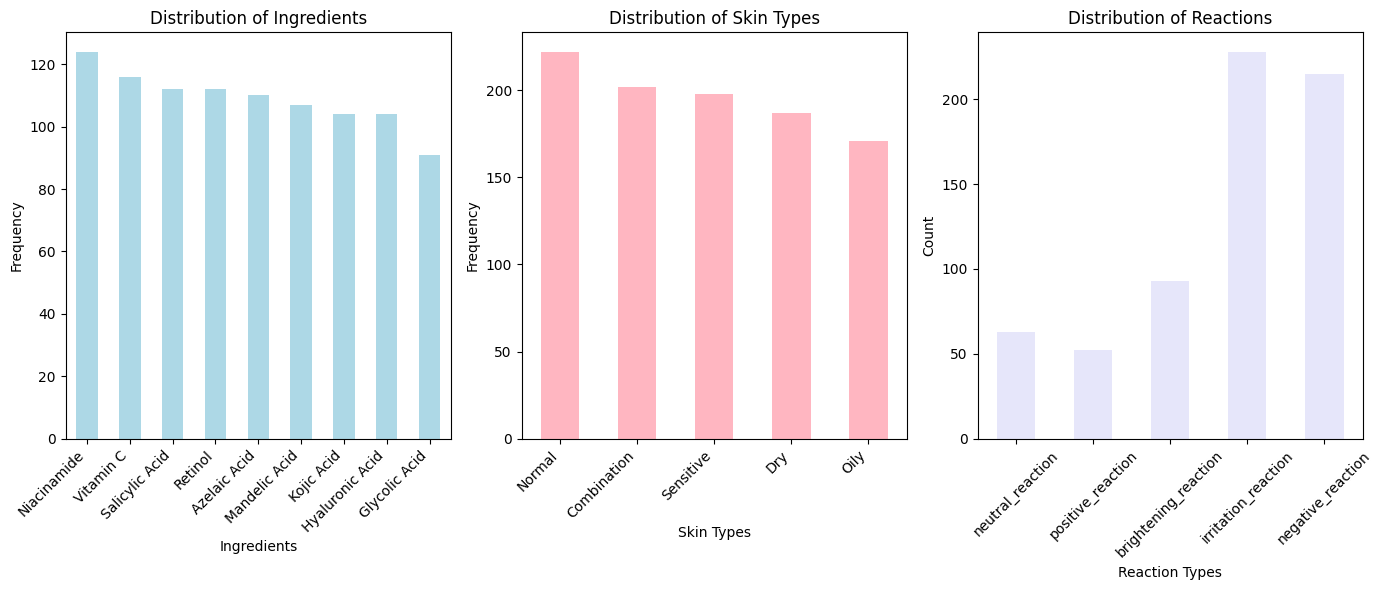

<Figure size 640x480 with 0 Axes>

In [7]:
# Plot histograms for each reaction type with respect to ingredients
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12))

reaction_columns = ['neutral_reaction', 'positive_reaction', 'brightening_reaction',
                    'irritation_reaction', 'negative_reaction']

# Set up a figure with 1 row and 2 columns
plt.figure(figsize=(14, 6))

# Plot the histogram for 'ingredient'
plt.subplot(1, 3, 1)  # 1 row, 2 columns, 1st plot
df['ingredient'].value_counts().plot(kind='bar', color='lightblue')
plt.title('Distribution of Ingredients')
plt.xlabel('Ingredients')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')  # Rotate the x-axis labels for better readability

# Plot the histogram for 'skin_type'
plt.subplot(1, 3, 2)  # 1 row, 2 columns, 2nd plot
df['skin_type'].value_counts().plot(kind='bar', color='lightpink')
plt.title('Distribution of Skin Types')
plt.xlabel('Skin Types')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')  # Rotate the x-axis labels for better readability

# Count the number of '1's for each reaction type (which indicates the occurrence of a reaction)
reaction_counts = df[reaction_columns].sum()

# Plot the histogram (bar plot)
plt.subplot(1, 3, 3)
reaction_counts.plot(kind='bar', color='lavender')
plt.title('Distribution of Reactions')
plt.xlabel('Reaction Types')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


<ipython-input-8-fbc9a1c8e7ce>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='skin_type', y=feature, data=df, palette='coolwarm')
<ipython-input-8-fbc9a1c8e7ce>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='skin_type', y=feature, data=df, palette='coolwarm')
<ipython-input-8-fbc9a1c8e7ce>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='skin_type', y=feature, data=df, palette='coolwarm')
<ipython-input-8-fbc9a1c8e7ce>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0.

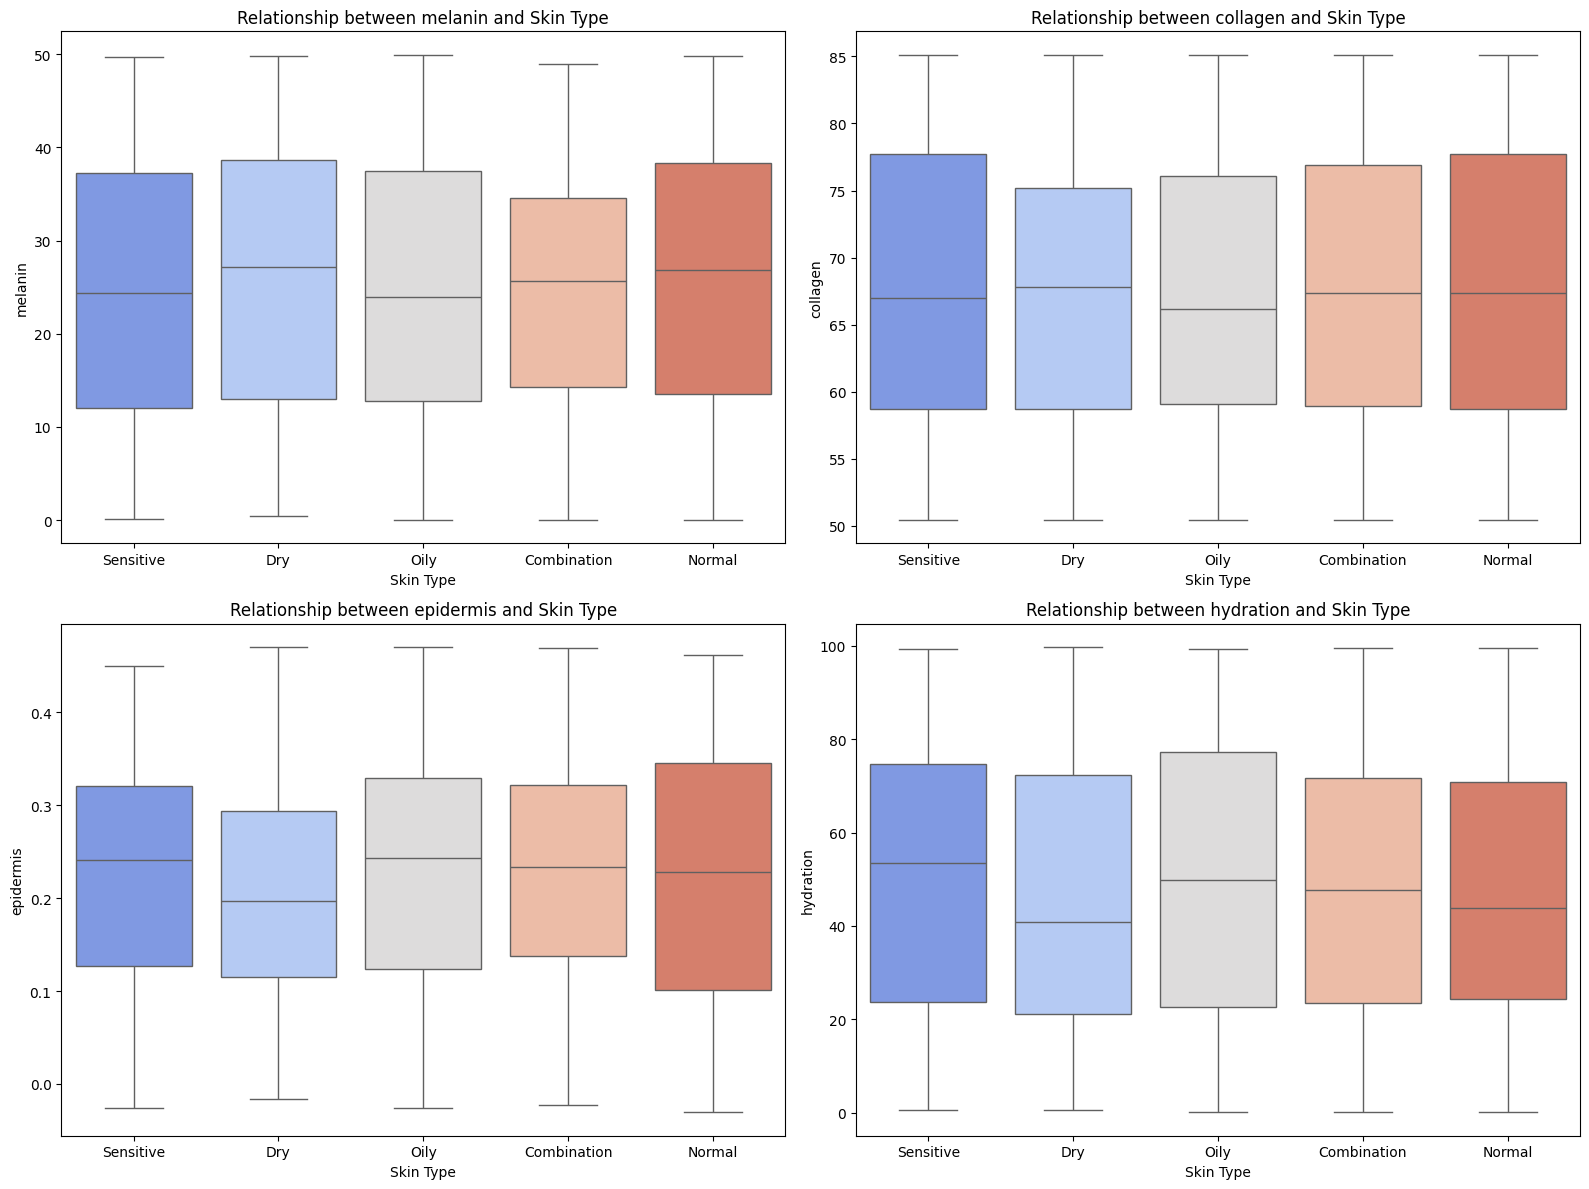

In [8]:
# Features to analyze
import seaborn as sns
skin_features = ['melanin', 'collagen', 'epidermis', 'hydration']
skin_types = df['skin_type'].unique()

# Plot relationships for each feature with skin type
plt.figure(figsize=(16, 12))

for i, feature in enumerate(skin_features):
    plt.subplot(2, 2, i + 1)  # Create a 2x2 grid of plots
    sns.boxplot(x='skin_type', y=feature, data=df, palette='coolwarm')
    plt.title(f'Relationship between {feature} and Skin Type')
    plt.xlabel('Skin Type')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

In [9]:
# One-hot encode 'skin_type' and 'ingredient'
df_encoded = pd.get_dummies(df, columns=['skin_type', 'ingredient'], drop_first=True)

# Ensure boolean columns are converted to integers
df_encoded = df_encoded.apply(lambda x: x.astype(int) if x.dtype == 'bool' else x)

# Convert reaction columns to integers
for column in reaction_columns:
    if column in df_encoded.columns:
        df_encoded[column] = df_encoded[column].astype(int)

df_encoded.head()

,age,melanin,collagen,epidermis,hydration,concentration,neutral_reaction,positive_reaction,brightening_reaction,irritation_reaction,...,skin_type_Oily,skin_type_Sensitive,ingredient_Glycolic Acid,ingredient_Hyaluronic Acid,ingredient_Kojic Acid,ingredient_Mandelic Acid,ingredient_Niacinamide,ingredient_Retinol,ingredient_Salicylic Acid,ingredient_Vitamin C
0,56,24.699074,53.752102,0.328596,63.223815,10.831598,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
1,46,37.731765,62.010655,0.212318,58.360504,7.275297,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,60,26.824068,50.448681,0.122448,35.513165,1.334878,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,25,18.941078,79.353617,0.411056,4.524919,2.457557,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
5,38,22.850011,68.617498,0.057433,21.790871,0.918132,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0


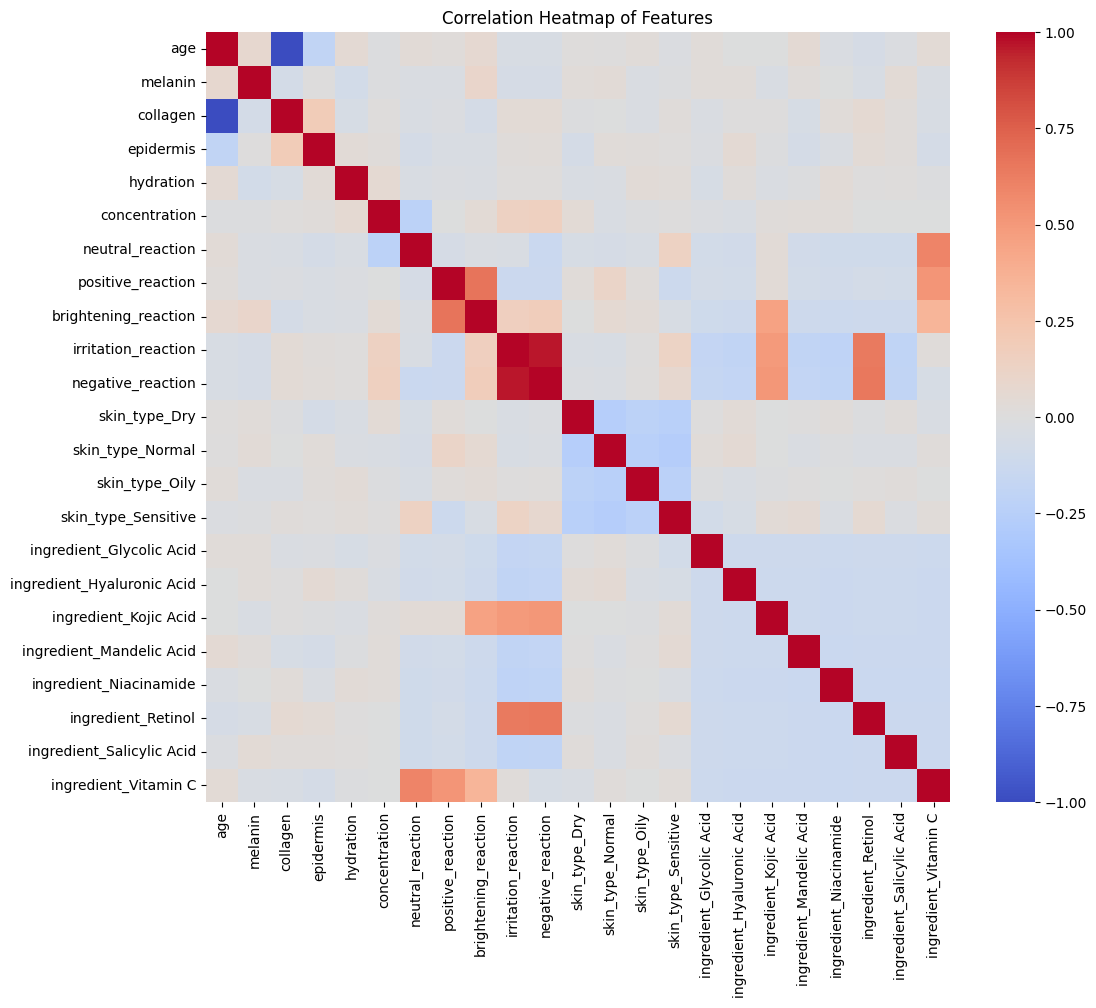

In [10]:
import seaborn as sns
plt.figure(figsize=(12, 10))

# Compute correlation
correlation_matrix = df_encoded.corr()

# Plot heatmap
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, fmt=".2f")
plt.title("Correlation Heatmap of Features")
plt.show()


# Model Set up

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, hamming_loss, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [12]:
# Define the target columns
target = ['neutral_reaction', 'positive_reaction',
          'brightening_reaction', 'irritation_reaction', 'negative_reaction']

# Separate features (X) and targets (Y)
x = df_encoded.drop(columns=target)  # Drop target columns from the features
y = df_encoded[target]               # Targets

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)


# Logistic regression with MultiOutputClassifier

In [13]:
#Logistic regression:
# Initialize and train the RandomForestRegressor model
log_model = MultiOutputClassifier(LogisticRegression(max_iter=1000, random_state=42))
log_model.fit(x_train, y_train)

# Evaluate the model
y_pred_log = log_model.predict(x_test)

for i, column in enumerate(y.columns):
    print(f"--- {column} ---")
    print(classification_report(y_test[column], y_pred_log[:, i]))

--- neutral_reaction ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       276
           1       1.00      0.83      0.91        18

    accuracy                           0.99       294
   macro avg       0.99      0.92      0.95       294
weighted avg       0.99      0.99      0.99       294

--- positive_reaction ---
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       276
           1       1.00      0.06      0.11        18

    accuracy                           0.94       294
   macro avg       0.97      0.53      0.54       294
weighted avg       0.95      0.94      0.92       294

--- brightening_reaction ---
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       261
           1       0.73      0.33      0.46        33

    accuracy                           0.91       294
   macro avg       0.83      0.66      0.71     

# Random Forest with MultiOutputClassifier

In [14]:
rf_model = MultiOutputClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
rf_model.fit(x_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(x_test)

# Evaluate
print("Random Forest Results:")
for i, column in enumerate(y.columns):
    print(f"--- {column} ---")
    print(classification_report(y_test[column], y_pred_rf[:, i]))

Random Forest Results:
--- neutral_reaction ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       276
           1       1.00      0.56      0.71        18

    accuracy                           0.97       294
   macro avg       0.99      0.78      0.85       294
weighted avg       0.97      0.97      0.97       294

--- positive_reaction ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       276
           1       1.00      0.56      0.71        18

    accuracy                           0.97       294
   macro avg       0.99      0.78      0.85       294
weighted avg       0.97      0.97      0.97       294

--- brightening_reaction ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       261
           1       1.00      0.85      0.92        33

    accuracy                           0.98       294
   macro avg       0.99  

# Xgboost with MultiOutputClassifier

In [15]:
xgb_base = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model = MultiOutputClassifier(xgb_base)

# Train the model
xgb_model.fit(x_train, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(x_test)

# Evaluate the model
print("XGBoost Multi-Label Classification Results:\n")
for i, column in enumerate(y.columns):
    print(f"--- {column} ---")
    print(classification_report(y_test[column], y_pred_xgb[:, i]))


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [23:47:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [23:47:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [23:47:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [23:47:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [23:47:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

XGBoost Multi-Label Classification Results:

--- neutral_reaction ---
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       276
           1       1.00      0.89      0.94        18

    accuracy                           0.99       294
   macro avg       1.00      0.94      0.97       294
weighted avg       0.99      0.99      0.99       294

--- positive_reaction ---
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       276
           1       1.00      0.89      0.94        18

    accuracy                           0.99       294
   macro avg       1.00      0.94      0.97       294
weighted avg       0.99      0.99      0.99       294

--- brightening_reaction ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       261
           1       1.00      0.97      0.98        33

    accuracy                           1.00       294
   

# Naive Bayes with MultiOutputClassifier

In [16]:
# Initialize MultiOutputClassifier with Naive Bayes
nb_model = MultiOutputClassifier(GaussianNB())
nb_model.fit(x_train, y_train)

# Predictions
y_pred_nb = nb_model.predict(x_test)

# Evaluate
print("Naive Bayes Results:")
for i, column in enumerate(y.columns):
    print(f"--- {column} ---")
    print(classification_report(y_test[column], y_pred_nb[:, i]))

Naive Bayes Results:
--- neutral_reaction ---
              precision    recall  f1-score   support

           0       1.00      0.73      0.85       276
           1       0.20      1.00      0.33        18

    accuracy                           0.75       294
   macro avg       0.60      0.87      0.59       294
weighted avg       0.95      0.75      0.81       294

--- positive_reaction ---
              precision    recall  f1-score   support

           0       1.00      0.70      0.83       276
           1       0.18      1.00      0.31        18

    accuracy                           0.72       294
   macro avg       0.59      0.85      0.57       294
weighted avg       0.95      0.72      0.79       294

--- brightening_reaction ---
              precision    recall  f1-score   support

           0       1.00      0.77      0.87       261
           1       0.36      1.00      0.53        33

    accuracy                           0.80       294
   macro avg       0.68    

# Neural Network

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler

In [18]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Convert data to PyTorch tensors
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

# Define a custom neural network class
class MultiLabelNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MultiLabelNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, hidden_size // 2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size // 2, output_size)
        self.sigmoid = nn.Sigmoid()  # Sigmoid activation for multi-label classification

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.sigmoid(x)
        return x

# Model setup
input_size = x_train.shape[1]
hidden_size = 128  # Number of neurons in the hidden layers
output_size = y_train.shape[1]

model = MultiLabelNN(input_size, hidden_size, output_size)

# Loss and optimizer
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training the model
epochs = 100
for epoch in range(epochs):
    # Forward pass
    outputs = model(x_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Evaluate the model
with torch.no_grad():
    y_pred = model(x_test_tensor)
    y_pred_binary = (y_pred > 0.5).int()  # Convert probabilities to binary (0/1)
    accuracy_nn = accuracy_score(y_test, y_pred_binary)
    hamming_loss_nn = hamming_loss(y_test, y_pred_binary)

# Print classification reports for each reaction
y_test_np = y_test.values
y_pred_np = y_pred_binary.numpy()

for i, column in enumerate(y.columns):
    print(f"--- Classification Report for {column} ---")
    print(classification_report(y_test_np[:, i], y_pred_np[:, i]))

--- Classification Report for neutral_reaction ---
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       276
           1       0.00      0.00      0.00        18

    accuracy                           0.94       294
   macro avg       0.47      0.50      0.48       294
weighted avg       0.88      0.94      0.91       294

--- Classification Report for positive_reaction ---
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       276
           1       0.00      0.00      0.00        18

    accuracy                           0.94       294
   macro avg       0.47      0.50      0.48       294
weighted avg       0.88      0.94      0.91       294

--- Classification Report for brightening_reaction ---
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       261
           1       0.00      0.00      0.00        33

    accuracy            

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

# Check the performance of Neural Network by plotting traning and testinig loss

Epoch [10/100], Training Loss: 0.1033, Testing Loss: 0.1231
Epoch [20/100], Training Loss: 0.0950, Testing Loss: 0.1157
Epoch [30/100], Training Loss: 0.0879, Testing Loss: 0.1098
Epoch [40/100], Training Loss: 0.0818, Testing Loss: 0.1048
Epoch [50/100], Training Loss: 0.0763, Testing Loss: 0.1005
Epoch [60/100], Training Loss: 0.0713, Testing Loss: 0.0964
Epoch [70/100], Training Loss: 0.0667, Testing Loss: 0.0927
Epoch [80/100], Training Loss: 0.0624, Testing Loss: 0.0892
Epoch [90/100], Training Loss: 0.0582, Testing Loss: 0.0855
Epoch [100/100], Training Loss: 0.0542, Testing Loss: 0.0819


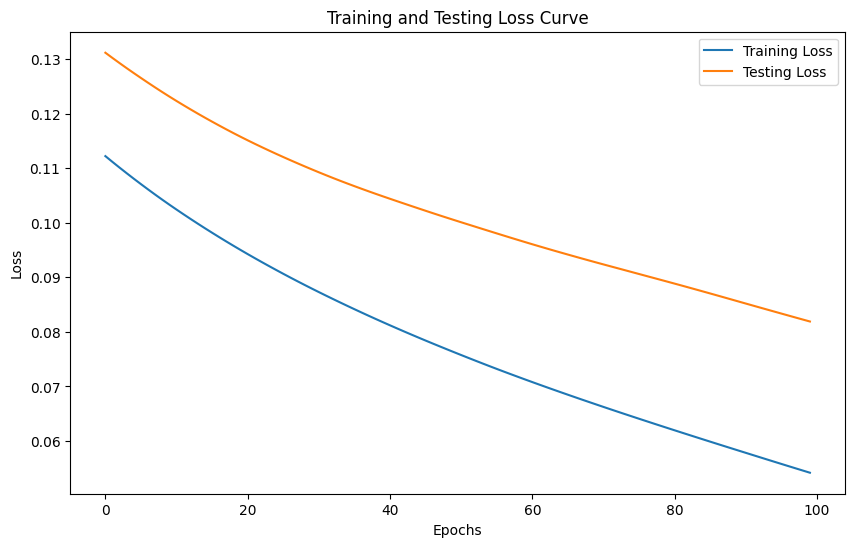

In [19]:
# Lists to store training and testing loss for visualization
train_losses = []
test_losses = []

# Training the model with testing loss tracking
epochs = 100
for epoch in range(epochs):
    # Forward pass
    model.train()
    outputs = model(x_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Record training loss
    train_losses.append(loss.item())

    # Evaluate testing loss
    model.eval()
    with torch.no_grad():
        test_outputs = model(x_test_tensor)
        test_loss = criterion(test_outputs, y_test_tensor)
        test_losses.append(test_loss.item())

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Training Loss: {loss.item():.4f}, Testing Loss: {test_loss.item():.4f}")

# Plot Training and Testing Loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(epochs), train_losses, label="Training Loss")
plt.plot(range(epochs), test_losses, label="Testing Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Testing Loss Curve")
plt.legend()
plt.show()


# Comparison between different models

Hamming Loss: measures the fraction of incorrectly predicted labels in a multi-label classification task.

In [20]:
results = []
results.append(["Logistic Regression", accuracy_score(y_test, y_pred_log), hamming_loss(y_test, y_pred_log)])
results.append(["Random Forest", accuracy_score(y_test, y_pred_rf), hamming_loss(y_test, y_pred_rf)])
results.append(["XGBoost", accuracy_score(y_test, y_pred_xgb), hamming_loss(y_test, y_pred_xgb)])
results.append(["Naive Bayes", accuracy_score(y_test, y_pred_nb), hamming_loss(y_test, y_pred_nb)])
results.append(["Neural Network", accuracy_nn, hamming_loss_nn])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Hamming Loss"])
results_df

,Model,Accuracy,Hamming Loss
0,Logistic Regression,0.867347,0.045578
1,Random Forest,0.928571,0.021769
2,XGBoost,0.986395,0.004762
3,Naive Bayes,0.598639,0.227891
4,Neural Network,0.806122,0.064626


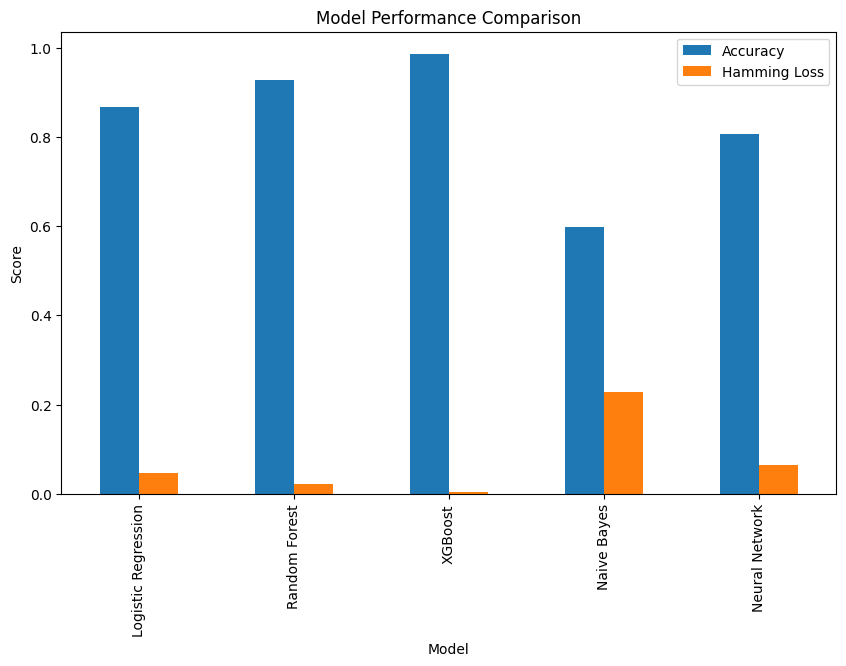

In [21]:
results_df.plot(kind="bar", x="Model", y=["Accuracy", "Hamming Loss"], figsize=(10, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()

# ROC Curve and AUC

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid

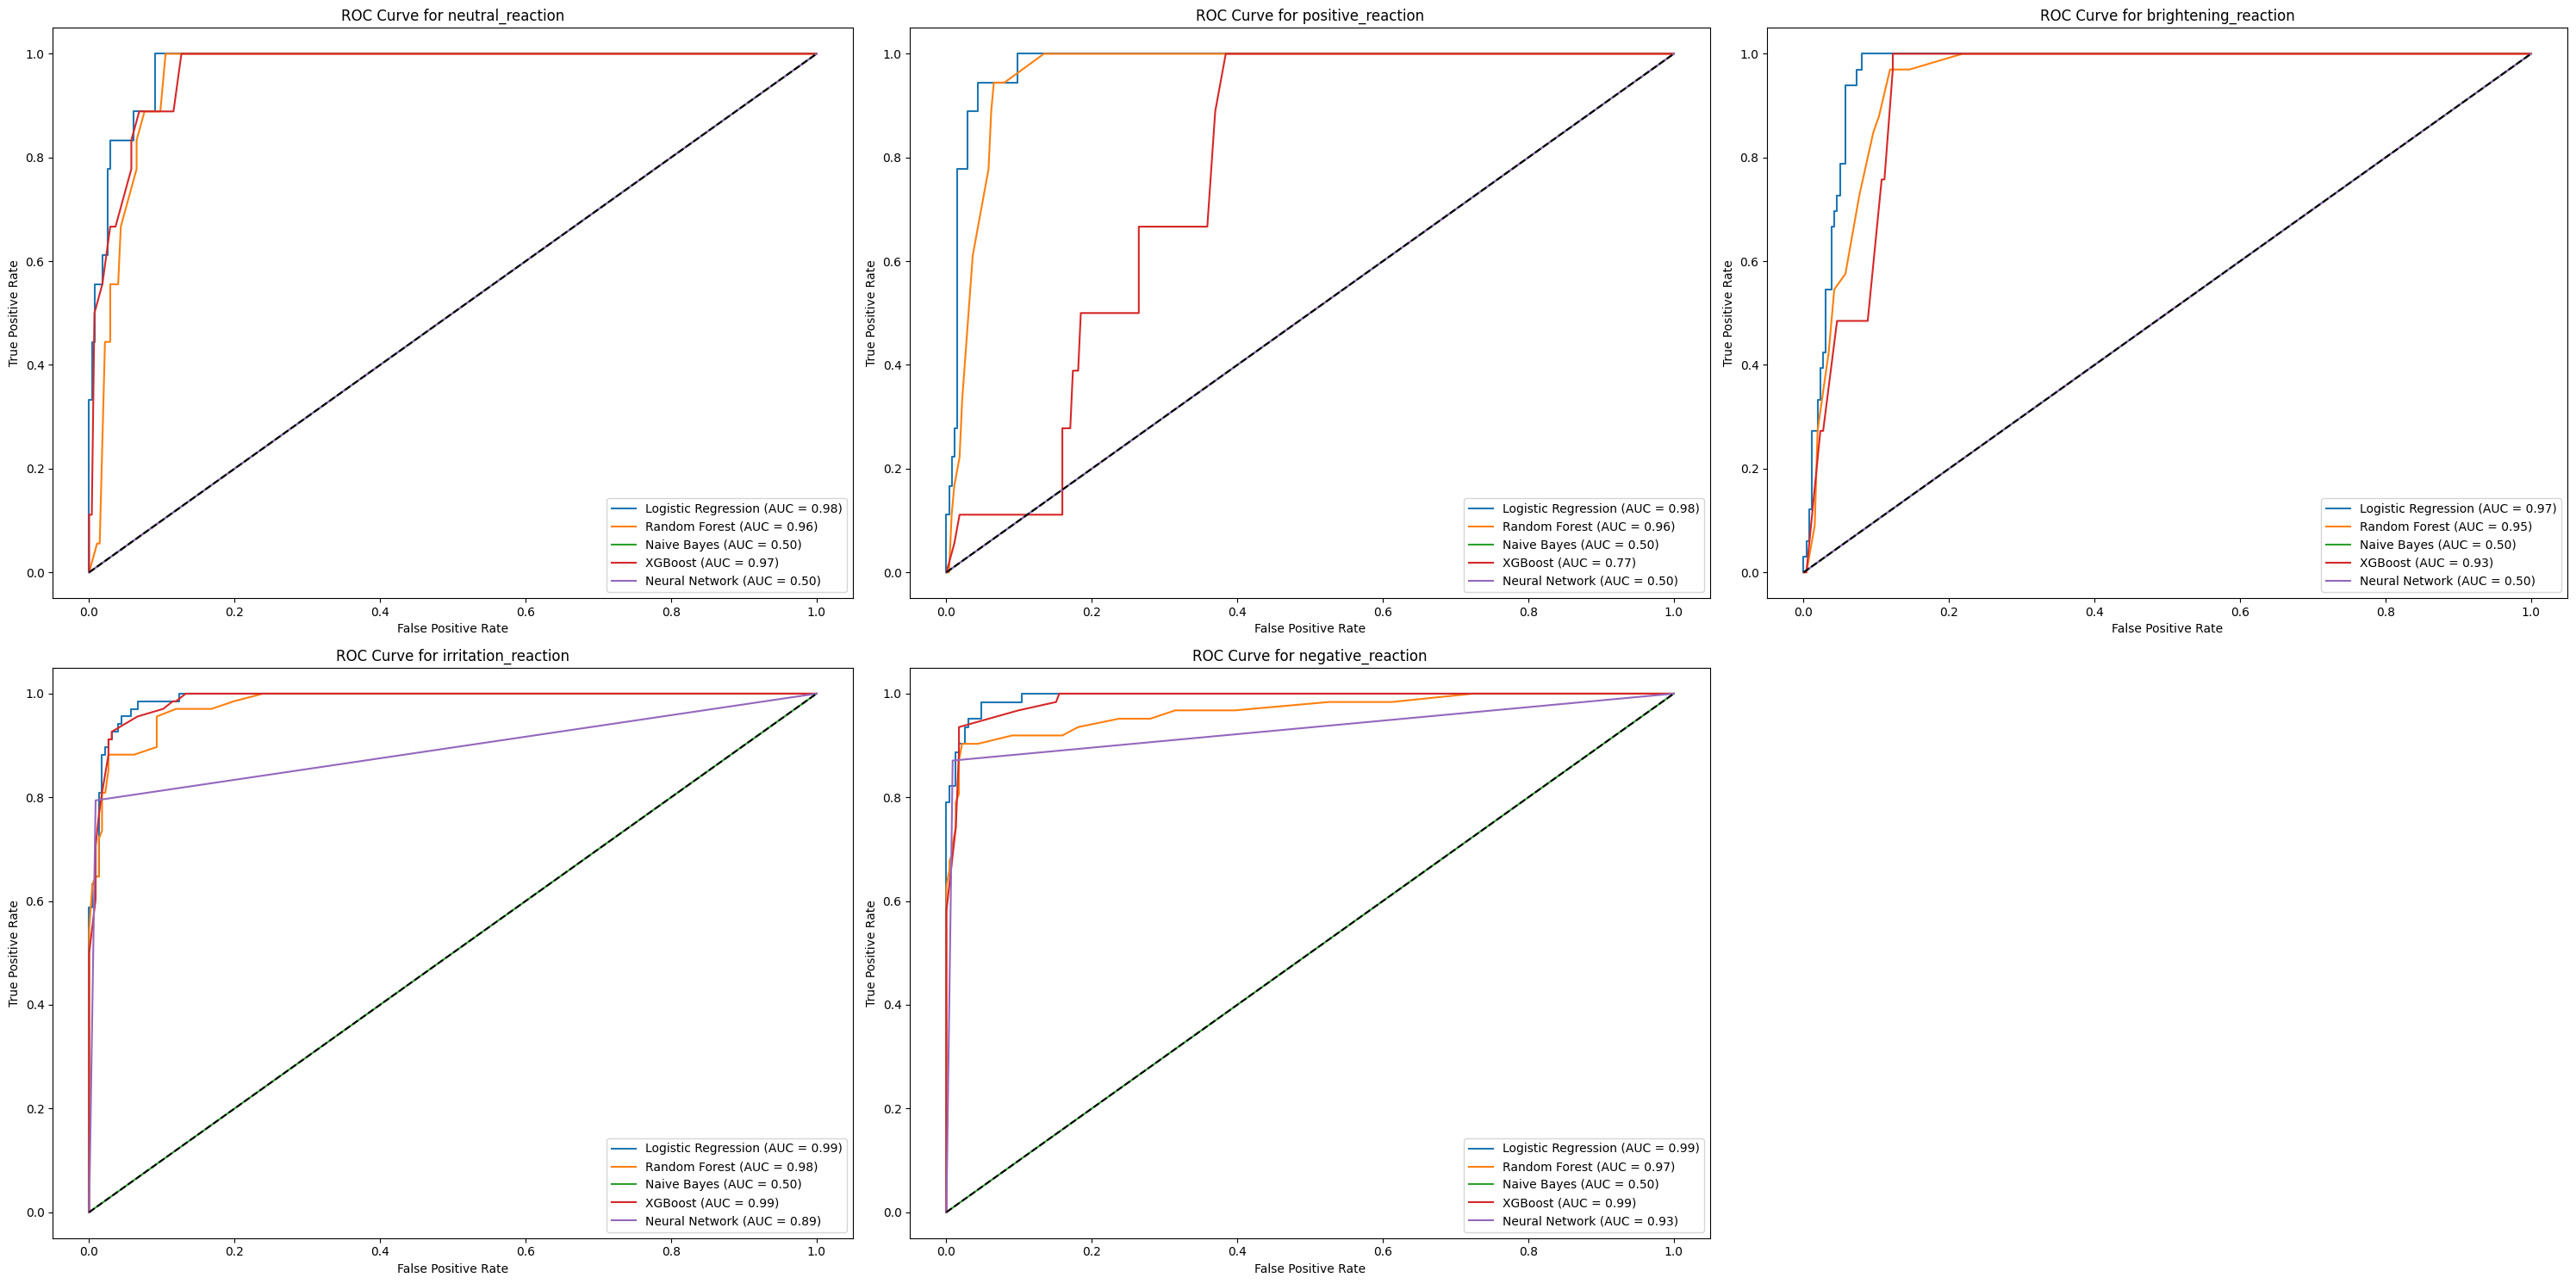

In [22]:
from sklearn.metrics import roc_curve, auc

# Helper function to calculate ROC curve and AUC for a model and reaction
def get_roc_data(model, X_test, y_test, reaction_index):
    if hasattr(model, "predict_proba"):  # For Sklearn Models
        y_pred_prob = model.predict_proba(X_test)[reaction_index][:, 1]
    else:  # For Neural Network
        y_pred_prob = y_pred_np[:, reaction_index]
    fpr, tpr, _ = roc_curve(y_test[:, reaction_index], y_pred_prob)
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

# Prepare test labels and predictions for NN
y_test_np = y_test.values
y_pred_nn_prob = y_pred.numpy()

# Define the models
models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "Naive Bayes": nb_model,
    "XGBoost": xgb_model,
    "Neural Network": "NeuralNet"
}

# Plot ROC Curves for Each Reaction
reactions = y_test.columns
plt.figure(figsize=(30, 15))

for i, reaction in enumerate(reactions):
    plt.subplot(2, 3, i + 1)
    for name, model in models.items():
        if name == "Neural Network":
            fpr, tpr, roc_auc = get_roc_data(None, None, y_test_np, i)
        else:
            fpr, tpr, roc_auc = get_roc_data(model, x_test, y_test_np, i)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
    plt.title(f"ROC Curve for {reaction}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

# Confusion Matrix

<Figure size 600x500 with 0 Axes>

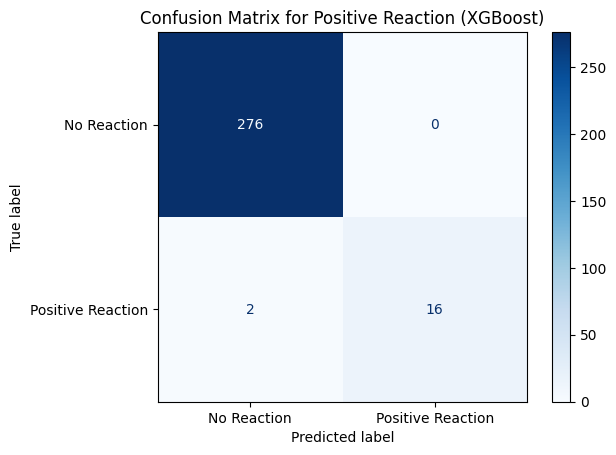

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Plot the confusion matrix for Positive Reaction
positive_reaction_index = y_test.columns.get_loc("positive_reaction")  # Get the index for Positive Reaction
cm = confusion_matrix(y_test.iloc[:, positive_reaction_index], y_pred_xgb[:, positive_reaction_index])

# Display the confusion matrix
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Reaction", "Positive Reaction"])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix for Positive Reaction (XGBoost)")
plt.show()